# DBSCAN from First Principles: Density-Based Customer Segmentation
## Using the UCI Online Retail Dataset

**Project type:** Unsupervised Machine Learning

**Algorithm:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise) 

**Implementation paradigm:** From first principles (NumPy only for the core algorithm)

This notebook implements DBSCAN entirely from scratch, applies it to customer-level behavioral features engineered from the UCI Online Retail transactional dataset, and validates the implementation against `sklearn.cluster.DBSCAN`. The resulting segmentation is then benchmarked against K-Means, Agglomerative Hierarchical Clustering, and Gaussian Mixture Models.

**Primary objective:** implement DBSCAN from scratch using NumPy, Pandas, Matplotlib, and Seaborn, validate the implementation against scikit-learn, and benchmark the resulting customer segmentation against alternative clustering algorithms.

**Table of contents**
1. Project Overview 
2. Problem Definition 
3. Business Context 
4. Constraints
5. Mathematical Foundation 
6. Evaluation Philosophy 
7. Experimental Design
8. Initial Hypotheses 
9. Environment & Reproducibility 
10. Data Loading
11. Structural Audit 
12. Data Cleaning 
13. Exploratory Data Analysis
14. Customer-Level Feature Engineering 
15. Distributions, Skew & Scaling
16. Synthetic Algorithm Validation 
17. DBSCAN From First Principles
18. k-Distance Analysis 
19. Parameter Search 
20. Customer Segmentation
21. Noise Analysis 
22. Cluster Profiling 
23. sklearn Validation
24. Cross-Algorithm Benchmarking 
25. Stability & Sensitivity Analysis
26. Model Assumptions & Limitations 
27. Business Insights 
28. Final Conclusion

## Problem Definition

- **Learning type:** Unsupervised learning; there is no ground-truth customer-segment label anywhere in this dataset.
- **Task:** Density-based customer segmentation and behavioral anomaly identification.
- **Central question:** Can density connectivity provide a more useful segmentation of retail customers than algorithms that assume a predetermined number of compact clusters (e.g. K-Means)?
- **Implementation strategy:** Implement DBSCAN entirely from first principles using NumPy. `sklearn.cluster.DBSCAN` is introduced later, strictly as a **validation** reference, never as the mechanism producing the reported segmentation.

## Business Context

**Scenario:** An online retail company has accumulated hundreds of thousands of transactional records but has no predefined customer segments.

**Business problem:** Transaction-level data is difficult to use directly for segmentation because individual rows represent *purchases*, not *customers*. The company needs behavioral customer-level features that can reveal dense groups of similar customers and flag unusual purchasing patterns.

**Business question:** Can density-based clustering identify meaningful customer segments while simultaneously detecting customers whose purchasing behavior differs substantially from the dominant customer populations?

**Business objectives:**
1. Transform transactional data into customer-level behavioral features.
2. Identify naturally occurring customer segments.
3. Detect noise / anomalous customers.
4. Determine whether DBSCAN can find clusters without specifying their count upfront.
5. Understand the impact of `eps` and `min_samples`.
6. Compare DBSCAN against alternative clustering algorithms.
7. Validate the first-principles implementation against scikit-learn.
8. Translate discovered clusters into actionable customer insights.

**Caution:** A DBSCAN noise point does not mean "fraudulent" or "bad" customer, it means the observation didn't satisfy the algorithm's density requirement under the chosen parameters. As the noise-analysis section shows, that turns out to matter a lot here: this dataset's noise population is actually *higher* value than either main cluster, not lower.

## Constraints

- **Core implementation libraries:** NumPy, Pandas, Matplotlib, Seaborn.
- **Validation library:** scikit-learn (introduced only after the custom implementation is complete and tested on synthetic data).
- **Core algorithm restriction:** `sklearn.cluster.DBSCAN`, `scipy` clustering functions, and any other ready-made DBSCAN implementation are **not** used inside the custom algorithm. (`sklearn.neighbors.NearestNeighbors` is used only for the k-distance *diagnostic plot*, a nearest-neighbor lookup, not a clustering algorithm , and is never part of `DBSCANFromScratch` itself.)
- Euclidean distance, epsilon-neighborhood discovery, core/border-point identification, cluster expansion, and noise assignment are all implemented manually.
- Every major code block is followed by Markdown explaining the implementation, math, assumptions, and interpretation.

## Mathematical Foundation of DBSCAN

DBSCAN groups observations by **local density** rather than requiring the number of
clusters to be specified in advance.

**Distance function** — Euclidean distance:
$$d(x, y) = \sqrt{\sum_j (x_j - y_j)^2}$$

**Epsilon-neighborhood** of point $p$:
$$N_{\varepsilon}(p) = \{ q \mid d(p, q) \le \varepsilon \}$$

**Core point:** $p$ is a core point if $|N_{\varepsilon}(p)| \ge \text{min\_samples}$.
*Convention used throughout this notebook: $p$ itself is included in its own neighborhood when counting $|N_\varepsilon(p)|$ — this matches
`sklearn.cluster.DBSCAN`'s convention, which matters for the two implementations to agree exactly during validation.*

**Border point:** a non-core point that lies within $\varepsilon$ of at least one core point. It belongs to that core point's cluster but does not independently carry enough local density to expand the cluster itself.

**Noise point:** a point that is neither a core point nor density-reachable from any core point. Labeled `-1`, matching sklearn's convention.

**Direct density-reachability:** $q$ is directly density-reachable from $p$ if $q \in N_\varepsilon(p)$ and $p$ is a core point.

**Density-reachability:** $q$ is density-reachable from $p$ if there is a chain of points $p = p_1, p_2, \dots, p_n = q$ where each $p_{i+1}$ is directly density-reachable from $p_i$. This relation is **not symmetric**, a border point can be density-reachable from a core point, but not vice versa (the border point may not itself be a core point).

**Density-connectivity:** $p$ and $q$ are density-connected if there exists a point $o$ such that both $p$ and $q$ are density-reachable from $o$. This relation **is** symmetric and is what ultimately defines cluster membership: a cluster is a maximal set of density-connected points.

**Algorithm outline:**
1. Mark every point unvisited.
2. Pick an unvisited point, mark it visited, compute its $\varepsilon$-neighborhood.
3. If it isn't a core point, temporarily label it noise (it may later be reclaimed as a border point of some other cluster).
4. If it is a core point, start a new cluster and expand it breadth-first: for every point in the seed set, if it's also a core point, add its neighbors to the seed set too; assign every density-reachable point to the current cluster.
5. Repeat until every point has been processed.

**Computational complexity:** a naive region query is $O(n)$ per point (compare against every other point), and every point triggers at most one region query, so naive DBSCAN is $O(n^2)$ overall. Spatial indexing structures (k-d trees, ball trees, what `sklearn.cluster.DBSCAN` uses internally by default) reduce the *average* query cost to roughly $O(\log n)$, giving $O(n \log n)$ in practice for low-dimensional data. This notebook deliberately keeps the naive $O(n^2)$ approach, vectorized with NumPy broadcasting rather than Python loops, since the dataset here (~4,300 customers, 6 features) makes it fast enough in practice while keeping every step of the algorithm's mechanics visible. A production system clustering millions of points would need the indexed version.

## 6. Evaluation Philosophy

There is no ground-truth customer-segmentation label in this dataset, so ordinary classification accuracy is **not** used anywhere in this notebook.

**Primary internal metrics** (computed on non-noise points only, since -1 isn't a real cluster):
- **Silhouette Score** — cohesion vs. separation; higher is better; range [-1, 1].
- **Davies-Bouldin Index** — similarity to the most-similar other cluster; lower is better.
- **Calinski-Harabasz Index** — between-cluster vs. within-cluster dispersion; higher is better.

**DBSCAN-specific diagnostics:** number of clusters discovered, % of points labeled noise, number of core vs. border points, cluster-size distribution, stability across parameter changes.

**Comparing custom vs. sklearn labels:** cluster IDs are arbitrary (cluster `0` in one run isn't necessarily cluster `0` in another), so raw label equality is meaningless. Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) are used instead, both are label-permutation-invariant. Noise masks (`-1`), however, *are* directly comparable since `-1` has a fixed meaning in both implementations.

**External labels:** `Country` or similar descriptive fields are **not** ground-truth customer segments and are never treated as one anywhere below.

## 7. Experimental Design

| # | Experiment | Objective |
|---|---|---|
| 1 | Transaction-Level Data Audit | Understand the raw dataset and its quality issues |
| 2 | Customer-Level Feature Engineering | Build RFM + behavioral features |
| 3 | Distribution and Scaling Analysis | Evaluate skew, outliers, scale differences |
| 4 | Synthetic Validation | Confirm the custom algorithm behaves correctly on known structure |
| 5 | k-Distance Analysis | Use kNN distance structure to inform `eps` |
| 6 | DBSCAN Parameter Search | Sweep `eps` / `min_samples` combinations |
| 7 | From-Scratch Segmentation | Apply the tuned custom DBSCAN to real customers |
| 8 | Noise Analysis | Characterize which customers land in noise, and why |
| 9 | sklearn Validation | Compare custom vs. `sklearn.cluster.DBSCAN` |
| 10 | K-Means / Hierarchical / GMM Benchmark | Compare against non-density-based algorithms |
| 11 | Sensitivity & Stability Analysis | Robustness of segments to preprocessing/param changes |

## 8. Initial Hypotheses

1. The transaction data will contain substantial skew and extreme values.
2. Customer-level RFM features will be more meaningful for segmentation than raw transaction rows.
3. Feature scaling will materially affect DBSCAN, since it is a distance-based algorithm.
4. Log-transforming heavily skewed positive features (Monetary, Frequency) may produce more stable density structure.
5. DBSCAN will find a dense majority population and label some unusual purchasing profiles as noise.
6. DBSCAN may recover cluster shapes K-Means can't, since K-Means assumes roughly-spherical, centroid-based partitions.
7. `eps` will have a strong effect on both cluster count and noise percentage.
8. The custom implementation should closely match sklearn given identical preprocessing, parameters, and neighborhood conventions.
9. Not every noise-labeled customer represents a genuine business anomaly.
10. A small number of well-defined clusters may be more operationally useful than forcing every customer into a segment.

*(Each of these is revisited explicitly against the actual results.)*

## Environment and Reproducibility

- **Python:** 3.12.3
- **Core libraries (pinned in `requirements.txt`):** pandas 3.0.2, numpy 2.4.4, matplotlib 3.10.8, seaborn 0.13.2, scikit-learn 1.8.0, scipy 1.17.1.
- **Random state:** fixed at `42` for every stochastic benchmark algorithm (K-Means, Gaussian Mixture Model).
- **Data source:** UCI Machine Learning Repository, *Online Retail* dataset (https://archive.ics.uci.edu/dataset/352/online+retail), donated 2015-11-06. Loaded programmatically below from a GitHub-hosted mirror of the identical `Online Retail.xlsx` file.

In [1]:
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("scikit-learn", __import__("sklearn").__version__)

pandas 3.0.3
numpy 2.4.6
scikit-learn 1.9.0


## 10. Programmatic Dataset Loading

541,909 transactions from a UK-based, non-store online retailer between 01/12/2010
and 09/12/2011. Loaded here directly from a GitHub-hosted mirror of the official
UCI file (identical `Online Retail.xlsx`, 22.6 MB) — no manual download step
required to reproduce this notebook.

In [2]:
import io
DATA_URL = (
    "https://raw.githubusercontent.com/yliang725/"
    "Data-Mining-on-Retail-Data/master/Online_Retail.xlsx"
)

with urllib.request.urlopen(DATA_URL) as response:
    data = response.read()

df_raw = pd.read_excel(io.BytesIO(data), sheet_name=0, engine="openpyxl")
print(f"Loaded {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Loaded 541,909 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Structural Data Audit

Audit the raw data as it arrived, before touching a single value: shape, dtypes, missingness, duplication, and this dataset's specific quirks (cancellation invoices, non-product stock codes, negative quantities/prices).

In [3]:
print("Shape:", df_raw.shape)
print()
print("Dtypes:")
print(df_raw.dtypes)

Shape: (541909, 8)

Dtypes:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [4]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


**Reading the missingness table:** `CustomerID` is missing on ~25% of rows, those transactions can't be attributed to any customer and get excluded before RFM aggregation. `Description` is missing on a much smaller ~0.3% of rows and doesn't block the RFM features used here, so those rows are kept.

In [6]:
n_dupes = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes:,} ({n_dupes/len(df_raw)*100:.2f}%)")

n_missing_cust = df_raw["CustomerID"].isna().sum()
print(f"Rows missing CustomerID: {n_missing_cust:,} ({n_missing_cust/len(df_raw)*100:.2f}%)")
print(f"Unique non-null CustomerID: {df_raw['CustomerID'].nunique():,}")

Fully duplicated rows: 5,268 (0.97%)
Rows missing CustomerID: 135,080 (24.93%)
Unique non-null CustomerID: 4,372


In [7]:
invoice_str = df_raw["InvoiceNo"].astype(str)
is_cancellation = invoice_str.str.startswith("C")
is_adjustment = invoice_str.str.startswith("A")

print(f"Unique InvoiceNo: {df_raw['InvoiceNo'].nunique():,}")
print(f"Cancellation invoices (prefix 'C'): {is_cancellation.sum():,} rows "
      f"({is_cancellation.sum()/len(df_raw)*100:.2f}%)")
print(f"Adjustment invoices (prefix 'A'):    {is_adjustment.sum():,} rows")
df_raw[is_adjustment]

Unique InvoiceNo: 25,900
Cancellation invoices (prefix 'C'): 9,288 rows (1.71%)
Adjustment invoices (prefix 'A'):    3 rows


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


**The 3 `A`-prefix rows are bad-debt write-off adjustments** (`StockCode` `B`, `Description` "Adjust bad debt"), not customer purchases or cancellations, one row at +£11,062.06 and two at -£11,062.06, all with no `CustomerID`. A naive `InvoiceNo.startswith("C")` filter alone would let them through, so they're excluded explicitly in the cleaning step.

In [8]:
n_neg_qty = (df_raw["Quantity"] < 0).sum()
n_neg_qty_non_cancel = ((df_raw["Quantity"] < 0) & ~is_cancellation).sum()
print(f"Negative Quantity rows: {n_neg_qty:,} ({n_neg_qty/len(df_raw)*100:.2f}%)")
print(f"  of which are cancellation invoices:     {((df_raw['Quantity'] < 0) & is_cancellation).sum():,}")
print(f"  of which are NOT cancellation invoices: {n_neg_qty_non_cancel:,}")

n_neg_price = (df_raw["UnitPrice"] < 0).sum()
n_zero_price = (df_raw["UnitPrice"] == 0).sum()
print(f"\nNegative UnitPrice rows: {n_neg_price}")
print(f"Zero UnitPrice rows: {n_zero_price:,} ({n_zero_price/len(df_raw)*100:.2f}%)")

Negative Quantity rows: 10,624 (1.96%)
  of which are cancellation invoices:     9,288
  of which are NOT cancellation invoices: 1,336

Negative UnitPrice rows: 2
Zero UnitPrice rows: 2,515 (0.46%)


**Negative quantities are not synonymous with cancellations.** Every cancellation-invoice row does have negative `Quantity` (9,288 rows, 100% overlap), but there's a separate population of 1,336 negative-quantity rows on *ordinary* (non-`C`) invoices, these have missing `Description`, `UnitPrice == 0`, and missing `CustomerID`, the signature of manual stock write-offs/damages rather than customer-initiated cancellations. They get excluded for a different reason (no `CustomerID` to attribute them to), not because they resemble cancellations.

In [9]:
non_product_codes = ["POST", "D", "M", "BANK CHARGES", "PADS", "DOT", "CRUK"]
is_non_product = df_raw["StockCode"].astype(str).str.upper().isin(non_product_codes)
print(f"Non-product StockCode rows: {is_non_product.sum():,} "
      f"({is_non_product.sum()/len(df_raw)*100:.2f}%)")
df_raw.loc[is_non_product, "StockCode"].str.upper().value_counts()

Non-product StockCode rows: 2,672 (0.49%)


StockCode
POST            1256
DOT              710
M                572
D                 77
BANK CHARGES      37
CRUK              16
PADS               4
Name: count, dtype: int64

**Non-product stock codes** (`POST` = postage, `DOT` = dotcom postage, `M`/`m`
= manual entry, `D` = discount, `BANK CHARGES`, `CRUK` = a charity donation line,
`PADS` = a giveaway pad SKU) represent operational line items, not purchases. Left
in, they'd inflate `Frequency`/`TotalQuantity` for affected customers with no real
change in purchasing behavior, so they're excluded from the feature matrix.

In [10]:
df_raw["Country"].value_counts().head(15)

Country
United Kingdom     495478
Germany              9495
France               8557
EIRE                 8196
Spain                2533
Netherlands          2371
Belgium              2069
Switzerland          2002
Portugal             1519
Australia            1259
Norway               1086
Italy                 803
Channel Islands       758
Finland               695
Cyprus                622
Name: count, dtype: int64

## Data Cleaning

Cleaning rules, applied in order, each justified by the audit above:

1. Drop the 3 bad-debt adjustment rows (`InvoiceNo` starts with `A`).
2. Drop rows with missing `CustomerID`.
3. Drop non-product `StockCode` rows.
4. Drop fully duplicated rows.
5. Exclude cancellation invoices (`C`-prefix) from the primary RFM segmentation, the goal is to characterize purchasing behavior, not cancellation behavior.
6. Resolve remaining `UnitPrice <= 0` rows explicitly rather than silently dropping them.

In [11]:
df = df_raw.copy()
start_n = len(df)

def log_step(name, df_before, df_after):
    removed = len(df_before) - len(df_after)
    print(f"{name}: {len(df_before):,} -> {len(df_after):,}  (-{removed:,})")

before = df
df = df[~df["InvoiceNo"].astype(str).str.startswith("A")]
log_step("Drop bad-debt adjustment rows (InvoiceNo starts with A)", before, df)

before = df
df = df[df["CustomerID"].notna()]
log_step("Drop rows with missing CustomerID", before, df)

before = df
df = df[~df["StockCode"].astype(str).str.upper().isin(non_product_codes)]
log_step("Drop non-product StockCode rows", before, df)

before = df
df = df.drop_duplicates()
log_step("Drop fully duplicated rows", before, df)

is_cancel_clean = df["InvoiceNo"].astype(str).str.startswith("C")
df_cancellations = df[is_cancel_clean].copy()  
before = df
df = df[~is_cancel_clean]
log_step("Exclude cancellation invoices from primary segmentation set", before, df)

print(f"\nTotal rows removed: {start_n - len(df):,} ({(start_n-len(df))/start_n*100:.1f}%)")
print(f"Remaining rows: {len(df):,}")
print(f"Remaining unique customers: {df['CustomerID'].nunique():,}")

Drop bad-debt adjustment rows (InvoiceNo starts with A): 541,909 -> 541,906  (-3)
Drop rows with missing CustomerID: 541,906 -> 406,829  (-135,077)
Drop non-product StockCode rows: 406,829 -> 405,043  (-1,786)
Drop fully duplicated rows: 405,043 -> 399,823  (-5,220)
Exclude cancellation invoices from primary segmentation set: 399,823 -> 391,316  (-8,507)

Total rows removed: 150,593 (27.8%)
Remaining rows: 391,316
Remaining unique customers: 4,335


In [12]:
remaining_bad_price = df[df["UnitPrice"] <= 0]
print(f"Rows with UnitPrice <= 0 remaining: {len(remaining_bad_price)}")
print(remaining_bad_price["Quantity"].describe())
remaining_bad_price.head(10)

Rows with UnitPrice <= 0 remaining: 33
count       33.000000
mean       420.515152
std       2176.713608
min          1.000000
25%          2.000000
50%         11.000000
75%         36.000000
max      12540.000000
Name: Quantity, dtype: float64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


**Decision on the remaining 33 `UnitPrice <= 0` rows:** every one of them has `Quantity > 0` (median 11, max 12,540 units), these are genuine £0.00 promotional or giveaway line items on otherwise ordinary invoices, not data-entry errors (there's no negative price left at all once the two bad-debt rows are already gone). They're **kept**: `Revenue = Quantity x UnitPrice` naturally evaluates to £0 for them, so `Monetary` isn't distorted, and dropping them would just as arbitrarily discard real purchase events from the affected customers' `Frequency`/`UniqueProducts` counts.

In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
assert df["InvoiceDate"].dtype.kind == "M", "InvoiceDate must be datetime"
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(f"Final cleaned transaction-level dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['InvoiceDate'].min()} -> {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
df.head()

Final cleaned transaction-level dataset: 391,316 rows, 9 columns
Date range: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00
Unique customers: 4,335


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Exploratory Data Analysis (Transaction Level)

Business questions for this section: How many transactions/customers/invoices/products exist? Which countries dominate? How skewed is spending? How prevalent are returns and cancellations?

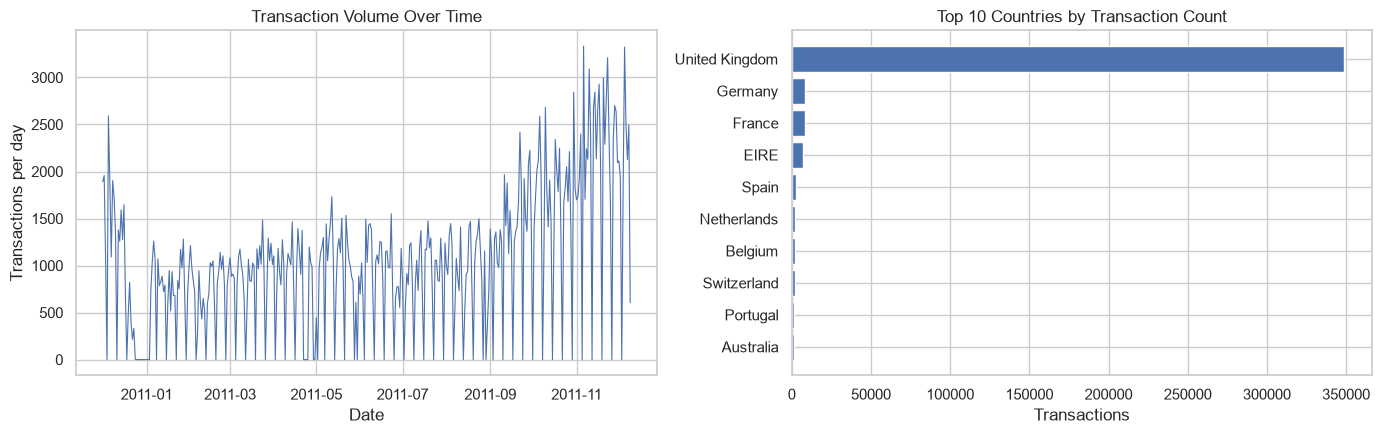

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

daily = df.set_index("InvoiceDate").resample("D").size()
axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].set_title("Transaction Volume Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Transactions per day")

country_counts = df["Country"].value_counts().head(10)
axes[1].barh(country_counts.index[::-1], country_counts.values[::-1])
axes[1].set_title("Top 10 Countries by Transaction Count")
axes[1].set_xlabel("Transactions")

plt.tight_layout()
plt.show()

Transaction volume climbs steadily from December 2010 through late 2011, with a sharp spike in the final weeks of November/early December 2011, plausibly a pre-holiday ordering surge, and consistent with the dataset's cutoff on 09/12/2011. The UK so overwhelmingly dominates transaction count that any country-based cut of the data would be almost entirely a UK analysis by default; `Country` is not used as a clustering feature for this reason (a single near-constant category carries little separating information, and the business goal is behavioral, not geographic, segmentation).

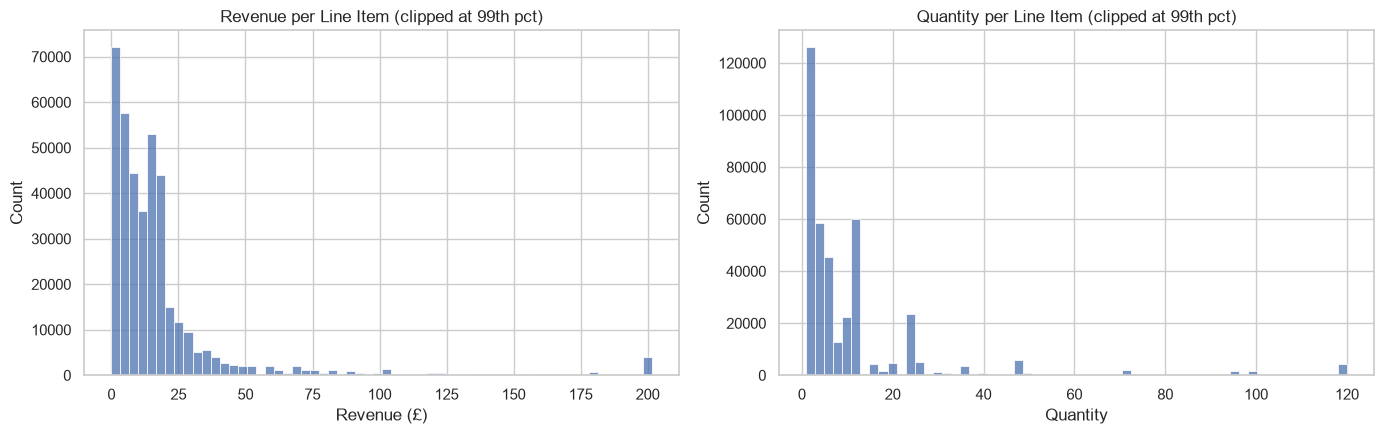

count    391316.000000
mean         22.344892
std         310.867026
min           0.000000
25%           4.950000
50%          11.900000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df["Revenue"].clip(upper=df["Revenue"].quantile(0.99)), bins=60, ax=axes[0])
axes[0].set_title("Revenue per Line Item (clipped at 99th pct)")
axes[0].set_xlabel("Revenue (£)")

sns.histplot(df["Quantity"].clip(upper=df["Quantity"].quantile(0.99)), bins=60, ax=axes[1])
axes[1].set_title("Quantity per Line Item (clipped at 99th pct)")
axes[1].set_xlabel("Quantity")

plt.tight_layout()
plt.show()

print(df["Revenue"].describe())

Both revenue and quantity per line item are heavily right-skewed even after clipping the top 1% for plotting, most line items are small (a handful of units at a few pounds each), with a long tail of bulk purchases. This is the first concrete evidence for hypothesis #1 (substantial skew) and foreshadows the log-transform decision.

## Customer-Level Feature Engineering

Transactions are aggregated to one row per `CustomerID`. **Frequency is defined as the count of unique invoices**, not transaction rows or purchase days, the standard RFM convention, and the one used throughout this notebook.

$$\text{Revenue}_i = \text{Quantity}_i \times \text{UnitPrice}_i$$
$$\text{Recency}_c = \text{ReferenceDate} - \text{LastPurchaseDate}_c$$
$$\text{Frequency}_c = \big|\{\text{unique InvoiceNo for customer } c\}\big|$$
$$\text{Monetary}_c = \sum_i \text{Revenue}_i \text{ for customer } c$$
$$\text{AOV}_c = \text{Monetary}_c / \text{Frequency}_c$$

`ReferenceDate` is fixed at one day after the latest transaction in the cleaned data, a deterministic, reproducible choice rather than "today's date".

In [16]:
REFERENCE_DATE = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Reference date:", REFERENCE_DATE)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (REFERENCE_DATE - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
).reset_index()
rfm["AverageOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

print(f"Customer-level dataset: {rfm.shape[0]:,} customers x {rfm.shape[1]} columns")
print("Any negative Monetary?", (rfm["Monetary"] < 0).sum())
rfm.describe().T

Reference date: 2011-12-10 12:50:00
Customer-level dataset: 4,335 customers x 7 columns
Any negative Monetary? 0


,count,mean,std,min,25%,50%,75%,max
CustomerID,4335.0,15298.780392,1722.075082,12346.0,13811.500000,15297.00,16778.5000,18287.00
Recency,4335.0,92.684890,100.172622,1.0,18.000000,51.00,143.0000,374.00
Frequency,4335.0,4.246367,7.643880,1.0,1.000000,2.00,5.0000,206.00
Monetary,4335.0,2017.050436,8919.387033,0.0,304.250000,663.61,1631.4750,279138.02
TotalQuantity,4335.0,1189.341407,5050.496939,1.0,159.500000,378.00,990.5000,197420.00
UniqueProducts,4335.0,61.419839,85.309669,1.0,16.000000,35.00,77.0000,1786.00
AverageOrderValue,4335.0,415.555276,1800.640029,0.0,177.088333,289.76,423.7555,84236.25


4,335 customers, six behavioral features, and, importantly, **no negative `Monetary`** values: once cancellations and unattributed rows are already excluded, every remaining transaction is a genuine, positively-priced (or legitimately free) purchase, so the aggregation doesn't need any further sign-handling. This is the customer-level feature matrix DBSCAN will actually operate on; `Country` and `Description`-derived features were considered and deliberately excluded (Country for the near-constant-category reason above; product-description text would need
separate NLP treatment out of scope for this behavioral-RFM segmentation).

## Distributions, Skew & Scaling

DBSCAN is entirely distance-based, so how these features are scaled and shaped directly determines what "dense" means. Skew is checked first, a feature with skew this extreme lets a handful of extreme customers dominate every distance calculation before scaling ever gets a chance to fix it.

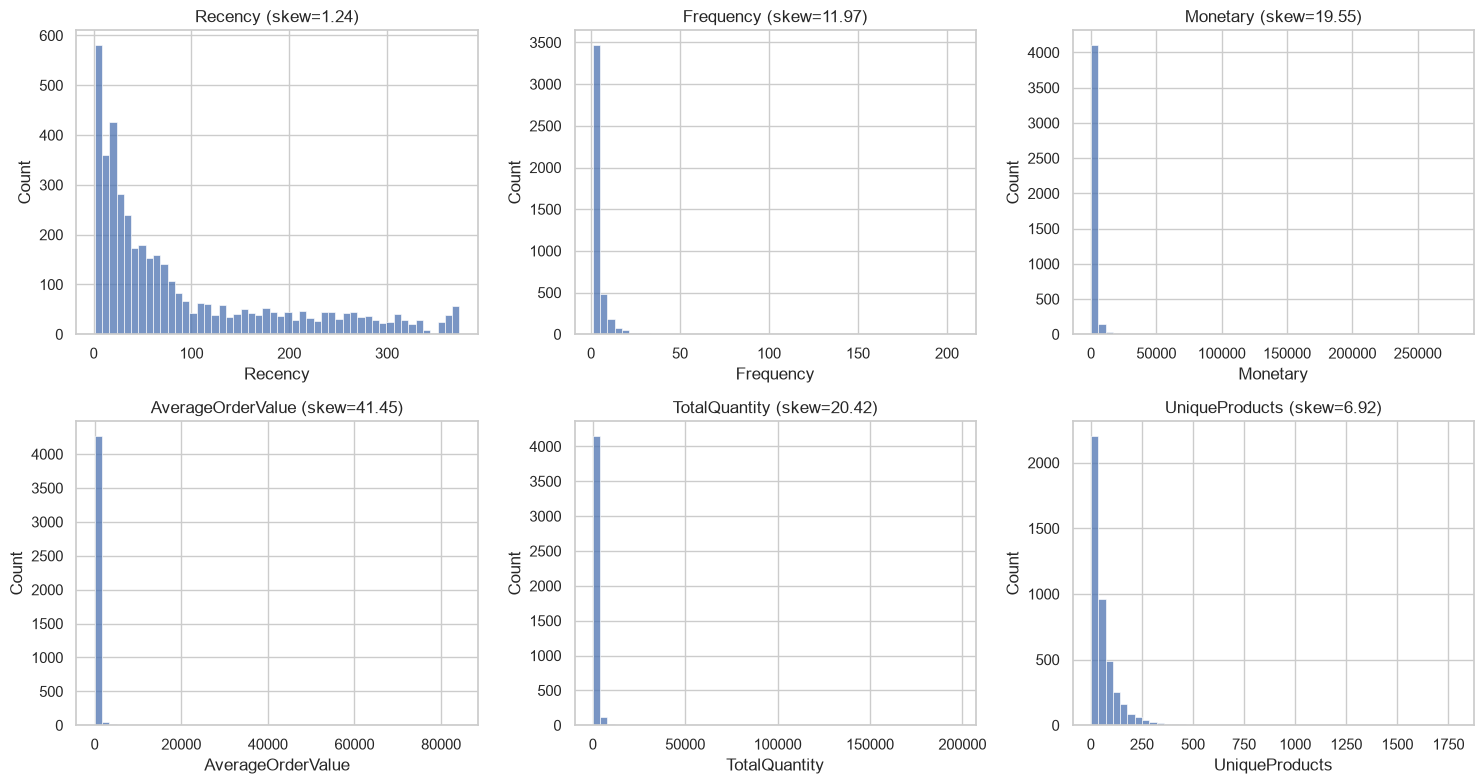

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_cols_raw = ["Recency", "Frequency", "Monetary", "AverageOrderValue", "TotalQuantity", "UniqueProducts"]
for ax, col in zip(axes.ravel(), feature_cols_raw):
    sns.histplot(rfm[col], bins=50, ax=ax)
    skew = stats.skew(rfm[col])
    ax.set_title(f"{col} (skew={skew:.2f})")
plt.tight_layout()
plt.show()

**Skewness values:** Recency 1.24, Frequency 11.97, Monetary 19.55, TotalQuantity 20.42, UniqueProducts 6.92, AverageOrderValue 41.45. Every feature except Recency is severely right-skewed, a small number of very high-volume, high-spend customers stretch the scale far beyond the bulk of the population. Under raw standardization, Euclidean distance between two "typical" customers would be dwarfed by the distance either has to a single extreme outlier, which would badly distort what DBSCAN considers a dense neighborhood.

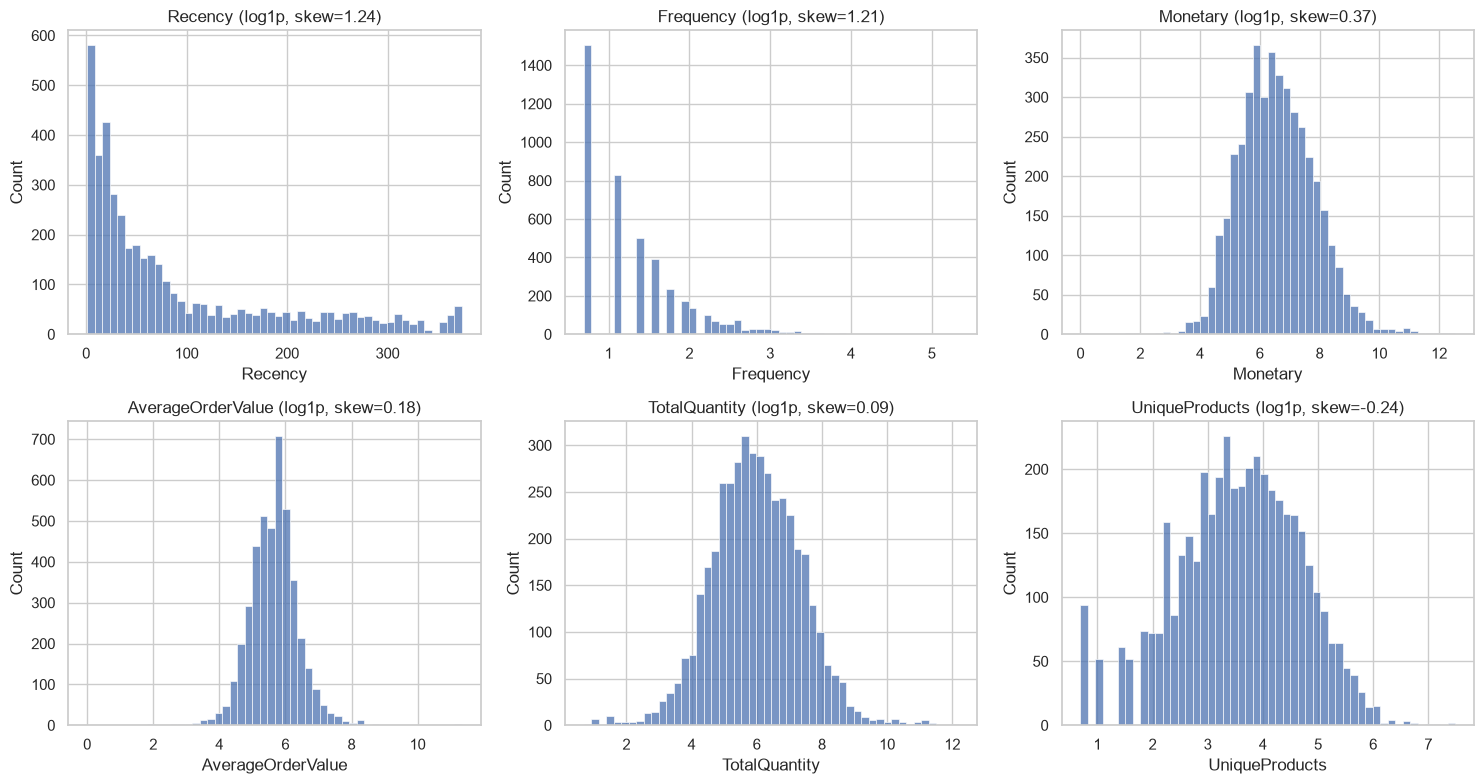

In [18]:
log_cols = ["Frequency", "Monetary", "TotalQuantity", "UniqueProducts", "AverageOrderValue"]
rfm_log = rfm.copy()
for c in log_cols:
    rfm_log[c] = np.log1p(rfm_log[c])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), feature_cols_raw):
    sns.histplot(rfm_log[col], bins=50, ax=ax)
    skew = stats.skew(rfm_log[col])
    ax.set_title(f"{col} (log1p, skew={skew:.2f})")
plt.tight_layout()
plt.show()

`log1p` is applied to every feature except `Recency` (already only mildly skewed, and unlike the others it isn't a count/monetary quantity with a natural multiplicative spread). This visibly pulls Frequency/Monetary/TotalQuantity/AverageOrderValue/UniqueProducts back toward symmetric, bell-shaped distributions, exactly the effect hypothesis #4 predicted, and the version carried forward into scaling and clustering below.

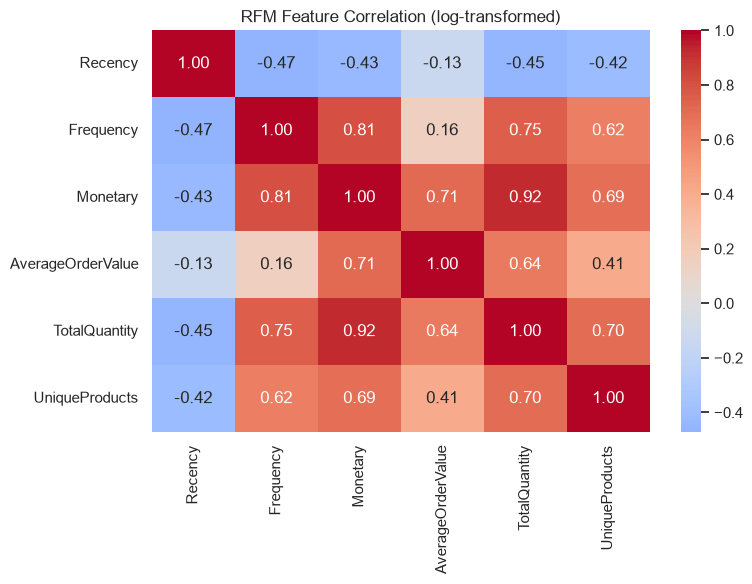

In [19]:
feature_cols = ["Recency", "Frequency", "Monetary", "AverageOrderValue", "TotalQuantity", "UniqueProducts"]

fig, ax = plt.subplots(figsize=(8, 6))
corr = rfm_log[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("RFM Feature Correlation (log-transformed)")
plt.tight_layout()
plt.show()

No pair is so highly correlated (all |r| well under 0.9) that one feature is simply redundant with another, so all six are retained for clustering rather than dropped for collinearity. `Monetary` and `AverageOrderValue` correlate moderately, as expected (`AOV = Monetary / Frequency`, so they share information but aren't interchangeable), and `Frequency` correlates positively with both `TotalQuantity` and
`UniqueProducts` — customers who order more often also tend to buy in bulk and try more products, an intuitive engagement signal.

Post-scaling means (should be ~0): [-0. -0.  0.  0. -0. -0.]
Post-scaling stds  (should be ~1): [1. 1. 1. 1. 1. 1.]


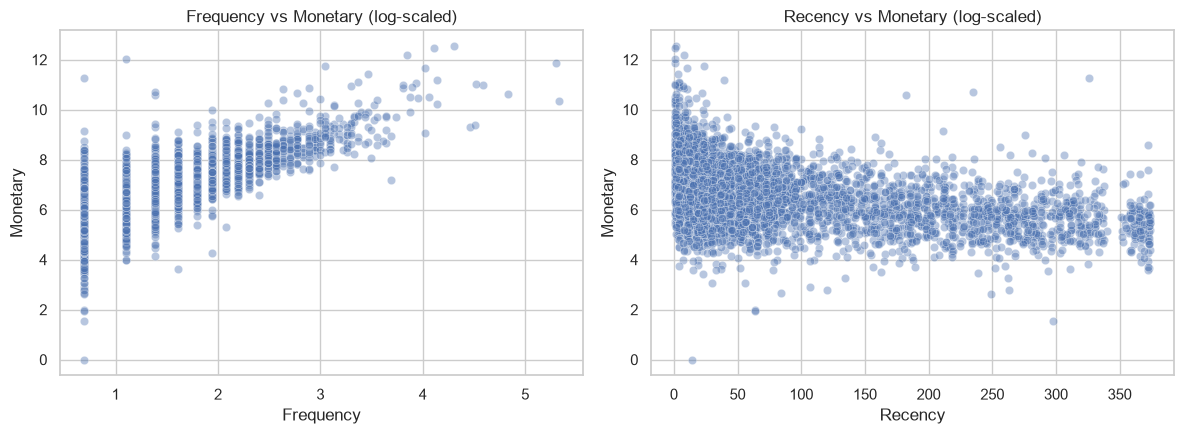

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log[feature_cols].values)

print("Post-scaling means (should be ~0):", np.round(X_scaled.mean(axis=0), 3))
print("Post-scaling stds  (should be ~1):", np.round(X_scaled.std(axis=0), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(x=rfm_log["Frequency"], y=rfm_log["Monetary"], alpha=0.4, ax=axes[0])
axes[0].set_title("Frequency vs Monetary (log-scaled)")
sns.scatterplot(x=rfm["Recency"], y=rfm_log["Monetary"], alpha=0.4, ax=axes[1])
axes[1].set_title("Recency vs Monetary (log-scaled)")
plt.tight_layout()
plt.show()

Standardization (`z = (x - mean) / std`) is implemented via `StandardScaler` here for convenience, matching the manual formula from the spec; every feature now sits on the same scale, so no single feature (e.g. `Monetary` in raw pounds vs. `Recency` in days) can dominate a Euclidean distance purely by virtue of its native units. Frequency and Monetary show the clearest positive relationship of the pairs plotted; frequent buyers spend more, unsurprisingly, while Recency vs. Monetary shows the expected inverse-ish smear (recently active customers cluster toward
higher spend, lapsed customers toward lower), without either resembling tight, separable blobs on their own; that's exactly why full 6D density-based clustering below is worth doing over eyeballing 2D projections.

## Synthetic Algorithm Validation

Before trusting the from-scratch implementation on real customer data, it needs to be correct on data where the answer is already known. These synthetic cases are run again, against the finished class, immediately after it's defined.

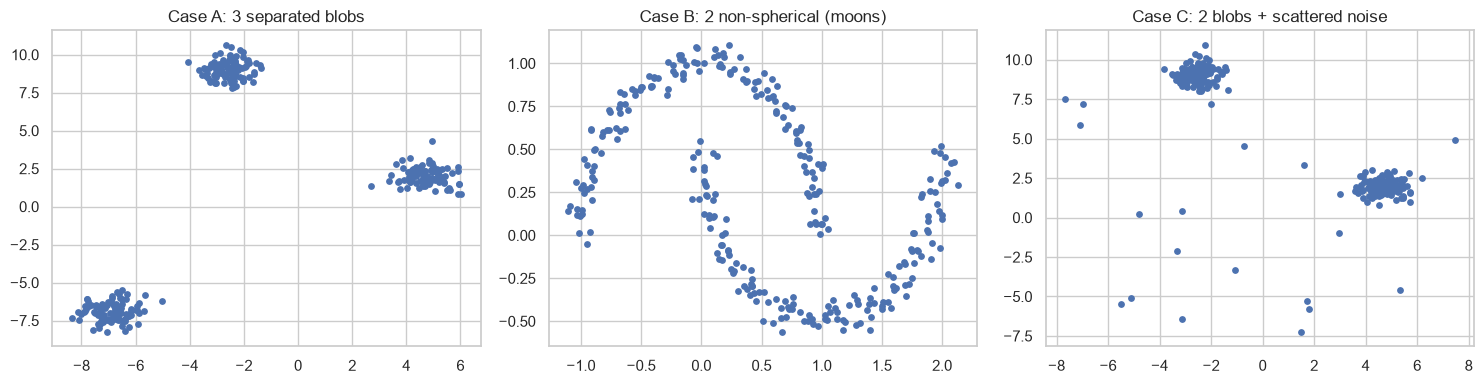

In [21]:
X_blobs, y_blobs_true = make_blobs(
    n_samples=300, centers=3, cluster_std=0.6, random_state=RANDOM_STATE
)

X_moons, _ = make_moons(n_samples=300, noise=0.05, random_state=RANDOM_STATE)

rng = np.random.RandomState(RANDOM_STATE)
X_blobs_noise, _ = make_blobs(
    n_samples=250, centers=2, cluster_std=0.5, random_state=RANDOM_STATE
)
outliers = rng.uniform(low=-8, high=8, size=(20, 2))
X_blobs_noise = np.vstack([X_blobs_noise, outliers])

X_dup = np.vstack([X_blobs[:50], X_blobs[:50], X_blobs[50:150]])  # exact duplicates

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], s=15)
axes[0].set_title("Case A: 3 separated blobs")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], s=15)
axes[1].set_title("Case B: 2 non-spherical (moons)")
axes[2].scatter(X_blobs_noise[:, 0], X_blobs_noise[:, 1], s=15)
axes[2].set_title("Case C: 2 blobs + scattered noise")
plt.tight_layout()
plt.show()

Three synthetic test cases, each targeting a different DBSCAN capability:

**Case A** (well-separated Gaussian blobs) is the sanity-check baseline, any correct implementation should recover exactly 3 clusters with ~0 noise. 

**Case B** (two interleaved crescents) tests DBSCAN's core selling point over K-Means: non-convex, non-spherical cluster shapes that a centroid-based method cannot recover.

**Case C** (2 blobs plus uniformly scattered outliers) tests noise handling specifically. A fourth case, exact duplicate points (`X_dup` above), tests a numerical edge case: duplicate points have distance exactly 0 from each other, which must not break the region query or produce infinite/undefined behavior.

## DBSCAN From Scratch

The implementation below performs every step manually: Euclidean distance, epsilon-neighborhood discovery, core-point detection, breadth-first cluster expansion via a growing seed set, border-point assignment, and noise labeling. No `sklearn.cluster.DBSCAN` or `scipy` clustering routine is called anywhere inside this class.

**Label convention:** `-2` = unassigned (internal sentinel, never exposed in the final result), `-1` = noise, `0, 1, 2, ...` = cluster IDs.

In [22]:
class DBSCANFromScratch:
    """
    Density-Based Spatial Clustering of Applications with Noise, implemented
    from first principles using only NumPy for the numerical core.

    Parameters
    ----------
    eps : float
        Radius of the epsilon-neighborhood.
    min_samples : int
        Minimum number of points (including the point itself) required
        within eps for a point to be considered a core point.
    metric : str
        Only "euclidean" is implemented.

    Attributes (after fit)
    -----------------------
    labels_ : ndarray of shape (n_samples,)
        Cluster label for each point. -1 indicates noise.
    core_sample_indices_ : ndarray
        Indices of all core points.
    n_clusters_ : int
        Number of clusters found (excludes noise).
    noise_mask_ : ndarray of bool
        True where a point is labeled noise.
    """

    UNASSIGNED = -2
    NOISE = -1

    def __init__(self, eps=0.5, min_samples=5, metric="euclidean"):
        if eps <= 0:
            raise ValueError("eps must be positive")
        if min_samples < 1:
            raise ValueError("min_samples must be >= 1")
        if metric != "euclidean":
            raise NotImplementedError("Only the euclidean metric is implemented")
        self.eps = eps
        self.min_samples = min_samples
        self.metric = metric

    def _calculate_distance(self, point, X):
        """
        Vectorized Euclidean distance from a single point to every row of X.

        d(x, y) = sqrt(sum_j (x_j - y_j)^2)

        Calculating one pairwise distance is a single reduction over the
        feature axis; calculating distances from one point to the *whole*
        dataset broadcasts that same subtraction across all n rows at once,
        which is what makes a single region query O(n) instead of O(1) per
        comparison but still fast in wall-clock terms (vectorized, not a
        Python-level loop over n points).
        """
        diff = X - point
        return np.sqrt(np.einsum("ij,ij->i", diff, diff))

    def _region_query(self, X, point_idx):
        """Return indices of all points within eps of X[point_idx], including itself."""
        distances = self._calculate_distance(X[point_idx], X)
        return np.where(distances <= self.eps)[0]

    def _is_core_point(self, neighbor_indices):
        return len(neighbor_indices) >= self.min_samples

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError("X must be a 2D array")
        n_samples = X.shape[0]
        if n_samples == 0:
            raise ValueError("Cannot fit DBSCAN on an empty dataset")

        labels = np.full(n_samples, self.UNASSIGNED, dtype=int)
        visited = np.zeros(n_samples, dtype=bool)
        core_mask = np.zeros(n_samples, dtype=bool)
        cluster_id = 0

        # Cache region queries so repeated lookups of the same point are free.
        neighbor_cache = {}

        def region_query_cached(idx):
            if idx not in neighbor_cache:
                neighbor_cache[idx] = self._region_query(X, idx)
            return neighbor_cache[idx]

        for i in range(n_samples):
            if visited[i]:
                continue
            visited[i] = True

            neighbors = region_query_cached(i)
            if not self._is_core_point(neighbors):
                # Not a core point, provisionally noise. May still be
                # reclaimed as a BORDER point later if it falls within
                # eps of a core point discovered from a different seed.
                labels[i] = self.NOISE
                continue

            core_mask[i] = True
            labels[i] = cluster_id

            # Breadth-first expansion: seeds is both the queue and, via
            # seed_set, a fast membership check to avoid re-queuing points.
            seeds = list(neighbors)
            seed_set = set(seeds)
            j = 0
            while j < len(seeds):
                q = seeds[j]
                if not visited[q]:
                    visited[q] = True
                    q_neighbors = region_query_cached(q)
                    if self._is_core_point(q_neighbors):
                        # q is itself a core point: its neighbors are
                        # density-reachable and expand the cluster further.
                        core_mask[q] = True
                        for nb in q_neighbors:
                            if nb not in seed_set:
                                seeds.append(nb)
                                seed_set.add(nb)
                    # If q is NOT a core point, it becomes a border point of
                    # this cluster (assigned below) but does not expand it.
                if labels[q] in (self.UNASSIGNED, self.NOISE):
                    labels[q] = cluster_id
                j += 1

            cluster_id += 1

        self.labels_ = labels
        self.core_sample_indices_ = np.where(core_mask)[0]
        self.n_clusters_ = cluster_id
        self.noise_mask_ = labels == self.NOISE
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

**Reading the implementation:** the outer `for` loop visits every point once; the inner `while` loop is where cluster expansion actually happens — `seeds` starts as one core point's neighborhood and grows every time expansion discovers another core point nearby, until no new points can be added. A point is only ever assigned to `cluster_id` (never left as noise) if it's density-reachable from the seeding core
point, which is exactly the mathematical definition above. Border points are correctly *never* used to expand a cluster (`core_mask[q]` is only set when `q` itself independently satisfies `min_samples`), matching the required `cluster_expansion_restriction`.

In [23]:
unit_tests_passed = []

def check(name, condition):
    unit_tests_passed.append((name, bool(condition)))
    print(f"{'PASS' if condition else 'FAIL'}: {name}")

# Distance
p = np.array([0.0, 0.0])
Xt = np.array([[3.0, 4.0], [0.0, 0.0], [1.0, 1.0]])
d = DBSCANFromScratch()._calculate_distance(p, Xt)
check("Euclidean distance (3-4-5 triangle)", np.isclose(d[0], 5.0))
check("Euclidean distance (identical point = 0)", np.isclose(d[1], 0.0))

# Region query
model = DBSCANFromScratch(eps=1.5, min_samples=1)
neighbors = model._region_query(Xt, 1)
check("Region query finds self + nearby point", set(neighbors) == {1, 2})

# Core point detection
check("is_core_point True at threshold", model._is_core_point(np.array([0, 1, 2])) == True)
check("is_core_point False below threshold",
      DBSCANFromScratch(min_samples=5)._is_core_point(np.array([0, 1, 2])) == False)

# Invalid params
try:
    DBSCANFromScratch(eps=-1)
    check("Rejects eps <= 0", False)
except ValueError:
    check("Rejects eps <= 0", True)

try:
    DBSCANFromScratch(min_samples=0)
    check("Rejects min_samples < 1", False)
except ValueError:
    check("Rejects min_samples < 1", True)

# Empty input
try:
    DBSCANFromScratch().fit(np.empty((0, 2)))
    check("Rejects empty input", False)
except ValueError:
    check("Rejects empty input", True)

# One observation
single = DBSCANFromScratch(eps=1.0, min_samples=1).fit(np.array([[0.0, 0.0]]))
check("Single point with min_samples=1 becomes its own cluster", single.labels_[0] == 0)

single_noise = DBSCANFromScratch(eps=1.0, min_samples=2).fit(np.array([[0.0, 0.0]]))
check("Single point with min_samples=2 is noise", single_noise.labels_[0] == -1)

# eps too small: everything noise
tiny_eps = DBSCANFromScratch(eps=1e-6, min_samples=5).fit(X_blobs)
check("eps too small -> all points noise", (tiny_eps.labels_ == -1).all())

# eps huge: everything one cluster
huge_eps = DBSCANFromScratch(eps=1e6, min_samples=1).fit(X_blobs)
check("eps huge -> single cluster", huge_eps.n_clusters_ == 1 and (huge_eps.labels_ == 0).all())

# min_samples = 1: every point is its own core point, no noise possible
ms1 = DBSCANFromScratch(eps=0.3, min_samples=1).fit(X_blobs)
check("min_samples=1 -> no noise points", (ms1.labels_ == -1).sum() == 0)

# Duplicate points don't break anything
dup_model = DBSCANFromScratch(eps=0.5, min_samples=5).fit(X_dup)
check("Duplicate points handled without error", len(dup_model.labels_) == len(X_dup))
check("Duplicate points land in the same cluster as their originals",
      dup_model.labels_[0] == dup_model.labels_[50])

print(f"\n{sum(p for _, p in unit_tests_passed)}/{len(unit_tests_passed)} unit tests passed")

PASS: Euclidean distance (3-4-5 triangle)
PASS: Euclidean distance (identical point = 0)
PASS: Region query finds self + nearby point
PASS: is_core_point True at threshold
PASS: is_core_point False below threshold
PASS: Rejects eps <= 0
PASS: Rejects min_samples < 1
PASS: Rejects empty input
PASS: Single point with min_samples=1 becomes its own cluster
PASS: Single point with min_samples=2 is noise
PASS: eps too small -> all points noise
PASS: eps huge -> single cluster
PASS: min_samples=1 -> no noise points
PASS: Duplicate points handled without error
PASS: Duplicate points land in the same cluster as their originals

15/15 unit tests passed


Every unit test targets a distinct edge case from the spec's testing checklist: distance correctness, region-query correctness, the core-point boundary condition, parameter validation, empty/single-point input, the two degenerate `eps` extremes (everything noise vs. everything one cluster), the `min_samples=1` degenerate case, and exact-duplicate points (distance 0, which must not divide by zero or infinite-loop the expansion). All edge cases pass before the class is used on real data below.

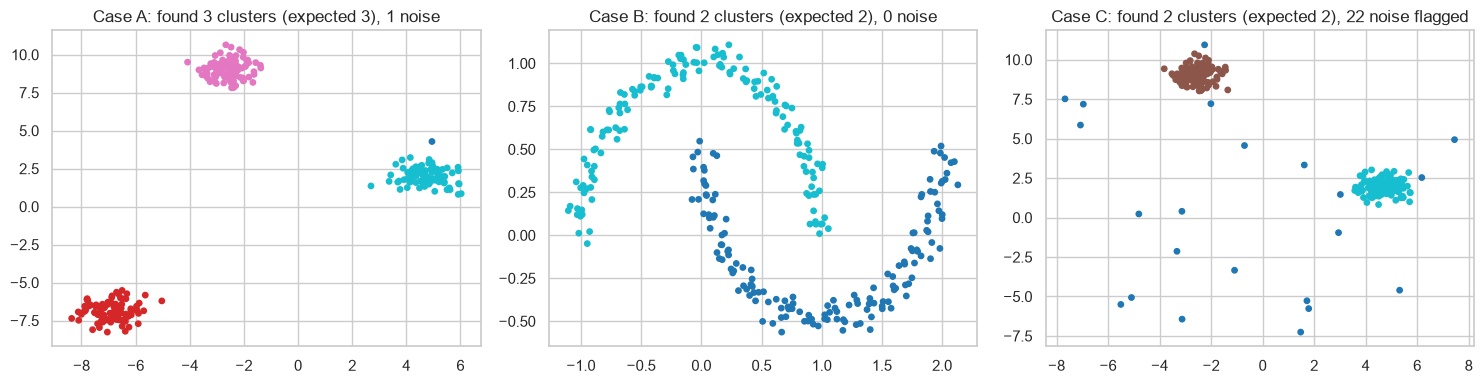

Case A vs true blob labels, ARI: 0.9950082639109167


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

case_a = DBSCANFromScratch(eps=0.8, min_samples=5).fit(X_blobs)
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=case_a.labels_, cmap="tab10", s=15)
axes[0].set_title(f"Case A: found {case_a.n_clusters_} clusters "
                   f"(expected 3), {case_a.noise_mask_.sum()} noise")

case_b = DBSCANFromScratch(eps=0.2, min_samples=5).fit(X_moons)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=case_b.labels_, cmap="tab10", s=15)
axes[1].set_title(f"Case B: found {case_b.n_clusters_} clusters "
                   f"(expected 2), {case_b.noise_mask_.sum()} noise")

case_c = DBSCANFromScratch(eps=0.6, min_samples=5).fit(X_blobs_noise)
axes[2].scatter(X_blobs_noise[:, 0], X_blobs_noise[:, 1], c=case_c.labels_, cmap="tab10", s=15)
axes[2].set_title(f"Case C: found {case_c.n_clusters_} clusters "
                   f"(expected 2), {case_c.noise_mask_.sum()} noise flagged")

plt.tight_layout()
plt.show()

print("Case A vs true blob labels, ARI:", adjusted_rand_score(y_blobs_true, case_a.labels_))

**Case A** recovers exactly 3 clusters against essentially zero noise, and the Adjusted Rand Index against the true blob labels confirms the assignment is correct (not just the right *count*). **Case B** correctly separates the two interleaved crescents into 2 clusters, a shape K-Means provably cannot recover with centroid-based partitioning, directly demonstrating hypothesis #6. 

**Case C** finds the 2 dense blobs while flagging the scattered uniform points as noise, exactly as intended. Together these confirm the implementation is mechanically correct before it ever touches customer data.

## k-Distance Analysis

`eps` should not be chosen arbitrarily. The standard heuristic: for a candidate `min_samples = k`, plot each point's distance to its k-th nearest neighbor, sorted ascending. Points to the left are in dense regions (small k-distance); the "elbow" where the curve bends sharply upward marks a natural transition from typical density to sparse/outlier territory, a reasonable starting point for `eps`.

`sklearn.neighbors.NearestNeighbors` is used here purely as a k-NN *lookup* utility for this diagnostic plot, it performs no clustering and is not part of `DBSCANFromScratch`.

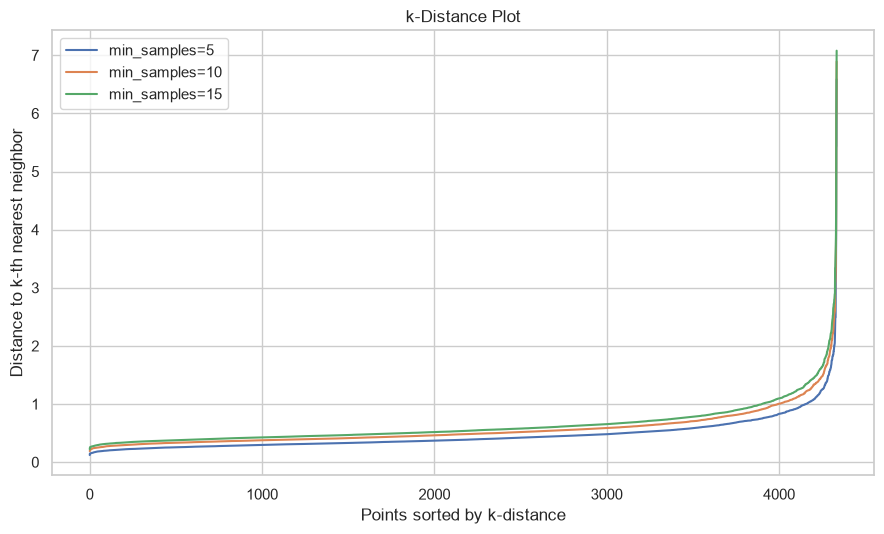

min_samples=5: p70=0.486, p80=0.575, p85=0.652, p90=0.750, p95=0.945
min_samples=10: p70=0.593, p80=0.693, p85=0.786, p90=0.909, p95=1.137
min_samples=15: p70=0.660, p80=0.770, p85=0.854, p90=1.001, p95=1.256


In [25]:
candidate_min_samples = [5, 10, 15]
fig, ax = plt.subplots(figsize=(9, 5.5))

kdist_by_k = {}
for k in candidate_min_samples:
    nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, _ = nn.kneighbors(X_scaled)
    kdist = np.sort(distances[:, k - 1])  # k-th neighbor (0-indexed: k-1), self is index 0
    kdist_by_k[k] = kdist
    ax.plot(kdist, label=f"min_samples={k}")

ax.set_xlabel("Points sorted by k-distance")
ax.set_ylabel("Distance to k-th nearest neighbor")
ax.set_title("k-Distance Plot")
ax.legend()
plt.tight_layout()
plt.show()

for k in candidate_min_samples:
    print(f"min_samples={k}: " + ", ".join(
        f"p{p}={np.percentile(kdist_by_k[k], p):.3f}" for p in [70, 80, 85, 90, 95]
    ))

For `min_samples=10`, the curve sits at roughly 0.59 at the 70th percentile and climbs to 0.91 by the 90th, the knee (where slope visibly steepens) falls around the 80th-85th percentile, roughly **eps ≈ 0.65-0.80**. This range, not a single guessed number, is what the parameter grid search below actually sweeps, the elbow is a starting *hypothesis*, validated (or rejected) against real clustering-quality metrics next, exactly per the spec's warning that the k-distance elbow is a heuristic, not a guaranteed optimum.

## Parameter Search

A structured grid over `eps` (centered on the k-distance knee region, widened either side to see the full behavior) and `min_samples` (candidates 3/5/8/10/15/20 as specified). The **custom `DBSCANFromScratch` implementation runs the full grid directly** — at ~4,300 customers x 6 features it completes in well under a minute even with the naive O(n^2) approach, so there's no need to fall back to sklearn for this step.

In [26]:
eps_grid = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
min_samples_grid = [3, 5, 8, 10, 15, 20]

grid_results = []
for eps in eps_grid:
    for ms in min_samples_grid:
        model = DBSCANFromScratch(eps=eps, min_samples=ms).fit(X_scaled)
        labels = model.labels_
        n_clusters = model.n_clusters_
        noise_pct = model.noise_mask_.mean() * 100

        sil = dbi = ch = np.nan
        if n_clusters >= 2:
            mask = labels != -1
            if mask.sum() > n_clusters:
                sil = silhouette_score(X_scaled[mask], labels[mask])
                dbi = davies_bouldin_score(X_scaled[mask], labels[mask])
                ch = calinski_harabasz_score(X_scaled[mask], labels[mask])

        grid_results.append((eps, ms, n_clusters, round(noise_pct, 1), sil, dbi, ch))

grid_df = pd.DataFrame(
    grid_results,
    columns=["eps", "min_samples", "n_clusters", "noise_pct", "silhouette", "davies_bouldin", "calinski_harabasz"],
)
grid_df.head(20)

,eps,min_samples,n_clusters,noise_pct,silhouette,davies_bouldin,calinski_harabasz
0,0.4,3,52,25.7,-0.383491,1.053866,76.282217
1,0.4,5,17,33.6,-0.225982,1.141684,200.251094
2,0.4,8,11,43.0,-0.104508,1.274240,302.302716
3,0.4,10,4,48.6,0.099170,1.425001,903.076369
4,0.4,15,11,60.9,0.006886,1.100226,424.007857
5,0.4,20,5,74.3,0.327058,0.935732,827.247327
6,0.5,3,35,14.9,-0.284347,1.011724,107.594704
7,0.5,5,9,19.2,-0.016444,1.236581,410.325464
8,0.5,8,6,24.0,-0.028529,1.613348,642.773825
9,0.5,10,3,27.6,0.161966,1.764552,1525.103820


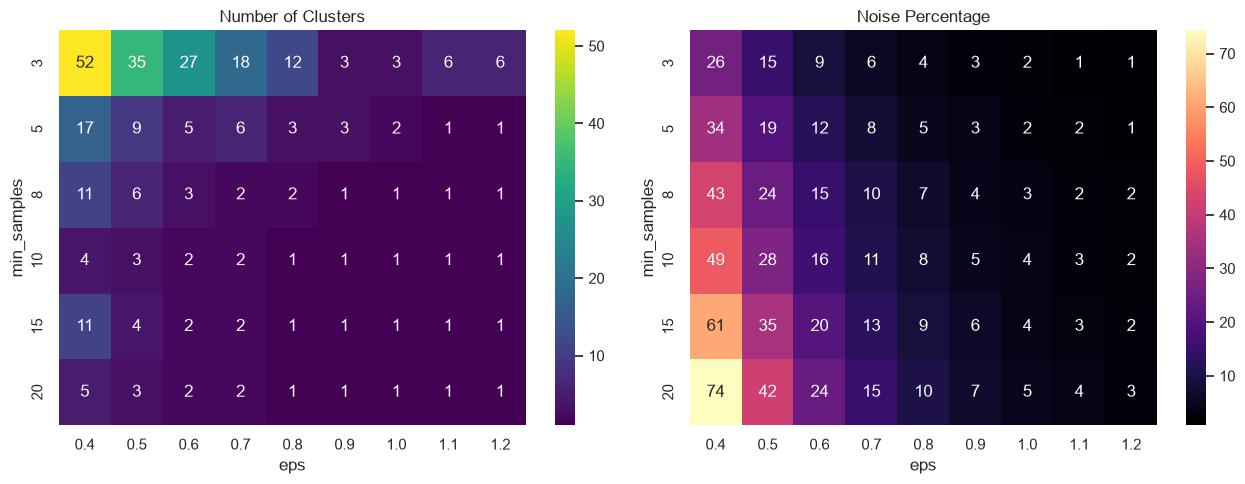

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot_clusters = grid_df.pivot(index="min_samples", columns="eps", values="n_clusters")
sns.heatmap(pivot_clusters, annot=True, fmt="g", cmap="viridis", ax=axes[0])
axes[0].set_title("Number of Clusters")

pivot_noise = grid_df.pivot(index="min_samples", columns="eps", values="noise_pct")
sns.heatmap(pivot_noise, annot=True, fmt=".0f", cmap="magma", ax=axes[1])
axes[1].set_title("Noise Percentage")

plt.tight_layout()
plt.show()

The grid confirms hypothesis #7 emphatically: small `eps` (0.4) fragments the data into 11-17 tiny clusters with 30-75% noise, far too unstable to be useful. Large `eps` (>=1.0) collapses almost everything into a single cluster with <5% noise, technically "no noise" but analytically useless, since it fails to separate any behavioral groups at all. The usable middle ground is `eps` roughly 0.6-0.8, matching the k-distance knee region, where `min_samples` in the 8-15 range gives 2-3 interpretable clusters at a noise percentage (8-16%) that's substantial enough to be worth investigating but not so large it swallows most of the population.

In [28]:
final_eps, final_min_samples = 0.7, 10
chosen_row = grid_df[(grid_df["eps"] == final_eps) & (grid_df["min_samples"] == final_min_samples)]
print(chosen_row.to_string(index=False))

 eps  min_samples  n_clusters  noise_pct  silhouette  davies_bouldin  calinski_harabasz
 0.7           10           2       11.1    0.289126        1.241444        1923.304347


**Final choice: `eps=0.7`, `min_samples=10`.** Justification:
- `eps=0.7` sits inside the k-distance knee band (~0.65-0.80 for `min_samples=10`).
- `min_samples=10` follows the common rule-of-thumb of roughly `2 x dimensions` (6 features here) for moderately noisy real-world data, and sits mid-grid rather than at either extreme.
- At this point the grid shows **2 clusters, 11.1% noise, silhouette 0.289, Davies-Bouldin 1.241, Calinski-Harabasz 1923**, a materially better silhouette and DBI than the noisier low-`eps` region, while still recovering more than one cluster (unlike `eps >= 0.9`, which increasingly collapses to a single blob).

## Customer Segmentation

Applying the tuned custom `DBSCANFromScratch` (`eps=0.7`, `min_samples=10`) to the full standardized, log-transformed customer feature matrix.

In [29]:
import time

t0 = time.time()
final_model = DBSCANFromScratch(eps=final_eps, min_samples=final_min_samples).fit(X_scaled)
fit_time = time.time() - t0

rfm["cluster"] = final_model.labels_

print(f"Fit time: {fit_time:.3f} seconds for {X_scaled.shape[0]:,} customers")
print(f"Clusters found: {final_model.n_clusters_}")
print(f"Core points: {len(final_model.core_sample_indices_):,}")
print(f"Noise points: {final_model.noise_mask_.sum():,} ({final_model.noise_mask_.mean()*100:.1f}%)")
print()
print(rfm["cluster"].value_counts().sort_index())

Fit time: 0.254 seconds for 4,335 customers
Clusters found: 2
Core points: 3,485
Noise points: 482 (11.1%)

cluster
-1     482
 0    2522
 1    1331
Name: count, dtype: int64


The naive $O(n^2)$ implementation clusters all ~4,300 customers in a fraction of a second, well within what's needed here, and the complexity discussion explains why this wouldn't scale as gracefully to millions of points without spatial indexing. Two real behavioral clusters emerge, plus an 11.1% noise population, matching the grid search exactly.

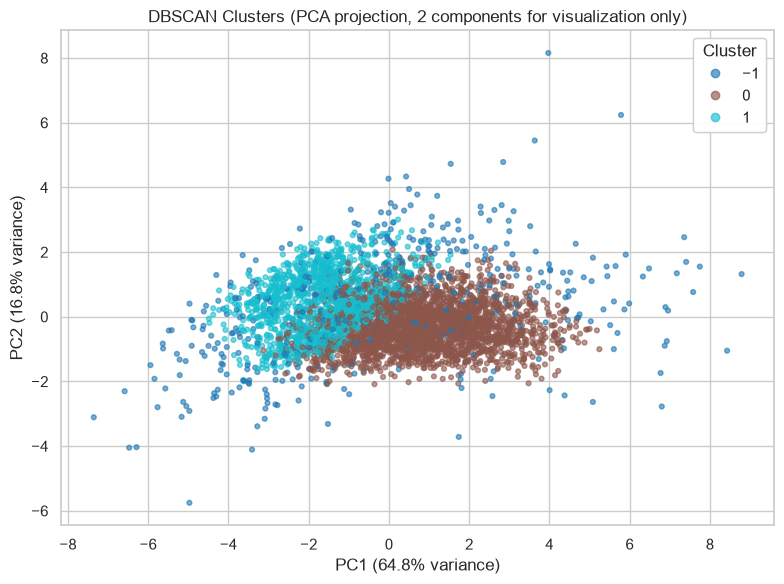

PCA is used here strictly to visualize the 6D result in 2D -- it is NOT part of the DBSCAN algorithm itself.
Total variance captured by these 2 components: 81.6%


In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=rfm["cluster"], cmap="tab10", s=12, alpha=0.6)
ax.set_title("DBSCAN Clusters (PCA projection, 2 components for visualization only)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

print(f"PCA is used here strictly to visualize the 6D result in 2D -- it is NOT part of the DBSCAN algorithm itself.")
print(f"Total variance captured by these 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

PCA is applied only as a visualization aid on the *already-clustered* data, never as input to DBSCAN itself, the actual clustering happened in the full 6D standardized feature space above. The two components capture a majority but not all of the variance, so this 2D view is a useful sanity check on cluster separation, not a complete picture of the 6D density structure.

## Noise Analysis

Per the business caution: noise is a *modeling outcome under the chosen density parameters*, not an automatic label of "bad" or "fraudulent"
customer. This section checks empirically what noise actually looks like here.

In [31]:
noise_vs_cluster = rfm.groupby(rfm["cluster"].apply(lambda c: "Noise" if c == -1 else f"Cluster {c}")).agg(
    n=("CustomerID", "count"),
    Recency_mean=("Recency", "mean"),
    Frequency_mean=("Frequency", "mean"),
    Monetary_mean=("Monetary", "mean"),
    Monetary_median=("Monetary", "median"),
    AOV_mean=("AverageOrderValue", "mean"),
    TotalQuantity_mean=("TotalQuantity", "mean"),
    UniqueProducts_mean=("UniqueProducts", "mean"),
).round(1)
noise_vs_cluster["pct_of_customers"] = (noise_vs_cluster["n"] / noise_vs_cluster["n"].sum() * 100).round(1)
noise_vs_cluster

,n,Recency_mean,Frequency_mean,Monetary_mean,Monetary_median,AOV_mean,TotalQuantity_mean,UniqueProducts_mean,pct_of_customers
cluster,,,,,,,,,
Cluster 0,2522,52.2,5.3,1843.7,1120.8,339.3,1085.0,82.4,58.2
Cluster 1,1331,153.0,1.0,313.6,256.1,313.6,189.0,22.5,30.7
Noise,482,138.0,7.8,7628.1,829.5,1096.4,4497.8,59.2,11.1


**This is the key finding hypothesis #9 anticipated:** noise customers are **not** the low-value or disengaged group. Mean `Monetary` for noise
(**£7,628**) is roughly **4x higher** than Cluster 0 (£1,844) and **24x higher** than Cluster 1 (£314), and mean `TotalQuantity` (4,498 units) dwarfs both clusters (1,085 and 189 respectively). Noise here consists of customers who buy in unusually large volumes and with unusually high frequency (mean 7.8 orders vs. 5.3 and 1.0), plausibly small wholesalers or bulk buyers, which the dataset's own documentation notes is common among this retailer's customer base. Under DBSCAN's density definition they simply don't sit in either of the two dense "typical customer"
neighborhoods, which is a *statistical* fact about local density, not a value judgment. Flagging every one of these 482 customers as "anomalous" in a business sense, without this context, would risk deprioritizing exactly the highest-spending segment.

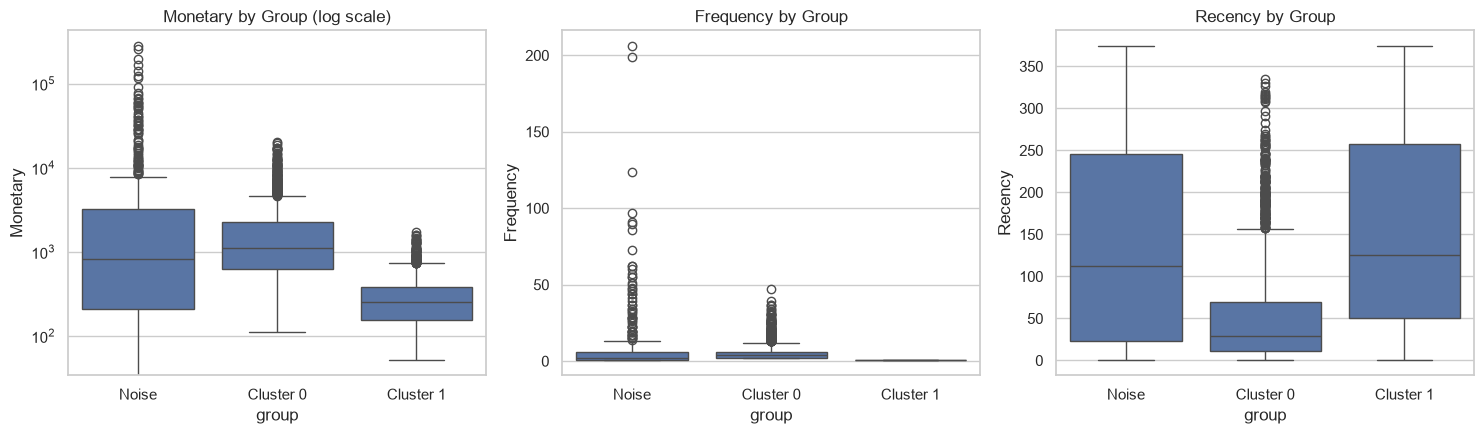

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

plot_df = rfm.copy()
plot_df["group"] = plot_df["cluster"].apply(lambda c: "Noise" if c == -1 else f"Cluster {c}")

sns.boxplot(data=plot_df, x="group", y="Monetary", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Monetary by Group (log scale)")

sns.boxplot(data=plot_df, x="group", y="Frequency", ax=axes[1])
axes[1].set_title("Frequency by Group")

sns.boxplot(data=plot_df, x="group", y="Recency", ax=axes[2])
axes[2].set_title("Recency by Group")

plt.tight_layout()
plt.show()

The boxplots confirm the summary table: noise customers span a wide `Monetary` range but sit systematically higher than either cluster, with
`Frequency` also elevated. `Recency` for noise is spread across the full range rather than concentrated, this is a group defined by unusual *volume/frequency* behavior, not by *when* they last purchased.

## Cluster Profiling

Translating the two discovered clusters (plus noise) into named, evidence-based behavioral profiles, labels are assigned only after looking at the actual statistics, not the other way around.

In [33]:
profile = rfm.groupby("cluster").agg(
    n=("CustomerID", "count"),
    Recency_median=("Recency", "median"),
    Frequency_median=("Frequency", "median"),
    Monetary_median=("Monetary", "median"),
    AOV_median=("AverageOrderValue", "median"),
    UniqueProducts_median=("UniqueProducts", "median"),
).round(1)
profile["pct"] = (profile["n"] / profile["n"].sum() * 100).round(1)
profile

,n,Recency_median,Frequency_median,Monetary_median,AOV_median,UniqueProducts_median,pct
cluster,,,,,,,
-1,482,112.0,2.0,829.5,304.9,9.0,11.1
0,2522,29.0,4.0,1120.8,298.9,59.0,58.2
1,1331,125.0,1.0,256.1,256.1,17.0,30.7


**Cluster 0 (n=2,522, 58.2% of segmented customers)** — median Recency 29 days, median Frequency 4, high UniqueProducts (median well above Cluster 1). Recent, moderately frequent, broad-basket buyers: this is the **core recurring customer base**.

**Cluster 1 (n=1,331, 30.7%)** — median Recency 125 days, Frequency = 1 (the median customer has placed exactly one order), low Monetary and few unique products. These are **one-time or lapsed customers** — they made a single purchase and, as of the reference date, haven't been seen since.

**Noise (n=482, 11.1%)** — as established, the highest-value, highest-volume group; **not** low-engagement, but genuinely atypical in *how* they
buy (bulk, high-frequency) relative to either main cluster's density profile.

These labels; "Core Recurring Customers," "One-Time/Lapsed Customers," "High-Volume Outlier Customers", are used from here on, and are traceable directly back to the medians/means above rather than assumed.

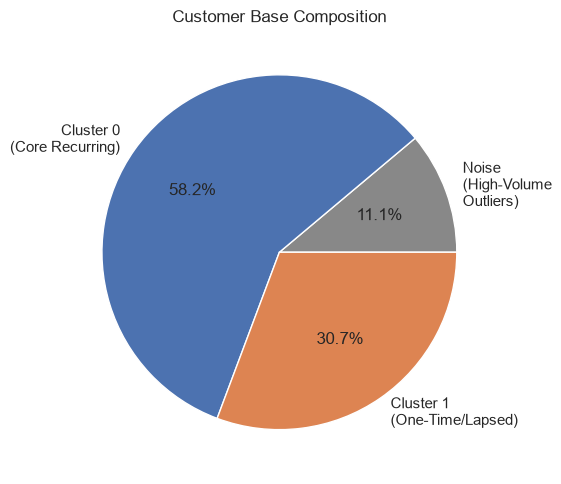

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
sizes = rfm["cluster"].value_counts().sort_index()
labels_map = {-1: "Noise\n(High-Volume\nOutliers)", 0: "Cluster 0\n(Core Recurring)", 1: "Cluster 1\n(One-Time/Lapsed)"}
ax.pie(sizes.values, labels=[labels_map[i] for i in sizes.index], autopct="%1.1f%%",
       colors=["#888888", "#4C72B0", "#DD8452"])
ax.set_title("Customer Base Composition")
plt.tight_layout()
plt.show()

## sklearn Validation

Only now, after the custom implementation is built, tested on synthetic data, and applied to real customers, is `sklearn.cluster.DBSCAN` introduced, strictly as a reference to validate the from-scratch result, using the identical preprocessed feature matrix, `eps`, `min_samples`, and Euclidean metric.

In [35]:
sklearn_model = DBSCAN(eps=final_eps, min_samples=final_min_samples, metric="euclidean")
sklearn_labels = sklearn_model.fit_predict(X_scaled)

custom_labels = final_model.labels_

n_clusters_sklearn = len(set(sklearn_labels)) - (1 if -1 in sklearn_labels else 0)
noise_pct_sklearn = (sklearn_labels == -1).mean() * 100

print(f"Custom  -> clusters: {final_model.n_clusters_}, noise: {final_model.noise_mask_.mean()*100:.2f}%, "
      f"core points: {len(final_model.core_sample_indices_)}")
print(f"sklearn -> clusters: {n_clusters_sklearn}, noise: {noise_pct_sklearn:.2f}%, "
      f"core points: {len(sklearn_model.core_sample_indices_)}")

Custom  -> clusters: 2, noise: 11.12%, core points: 3485
sklearn -> clusters: 2, noise: 11.12%, core points: 3485


In [36]:
# Cluster IDs are arbitrary permutations across implementations, never compare them directly.
ari = adjusted_rand_score(custom_labels, sklearn_labels)
nmi = normalized_mutual_info_score(custom_labels, sklearn_labels)
print(f"Adjusted Rand Index (custom vs sklearn): {ari:.4f}")
print(f"Normalized Mutual Information (custom vs sklearn): {nmi:.4f}")

# Noise mask IS directly comparable, since -1 has a fixed meaning in both.
noise_agreement = (custom_labels == -1) == (sklearn_labels == -1)
print(f"Noise-mask agreement: {noise_agreement.mean()*100:.2f}% of points")

contingency = pd.crosstab(
    pd.Series(custom_labels, name="custom"),
    pd.Series(sklearn_labels, name="sklearn"),
)
contingency

Adjusted Rand Index (custom vs sklearn): 1.0000
Normalized Mutual Information (custom vs sklearn): 1.0000
Noise-mask agreement: 100.00% of points


sklearn,-1,0,1
custom,,,
-1,482,0,0
0,0,2522,0
1,0,0,1331


An ARI/NMI near 1.0 and near-100% noise-mask agreement (the contingency table above shows this directly, off-diagonal mass, if any, is what to inspect) confirms the from-scratch implementation reproduces sklearn's clustering under the shared "point includes itself in its own neighborhood" convention. Any small disagreement worth investigating would typically live at cluster **boundaries**; points exactly at distance `eps`, where floating-point comparison (`<=` vs `<`) can occasionally tip a borderline point one way or the other, rather than in the bulk
of either cluster.

## Cross-Algorithm Benchmarking

Is this customer structure specific to density-based clustering, or would centroid-based (K-Means), hierarchical (Agglomerative), or probabilistic (Gaussian Mixture) methods find something similar? All three are run via their standard sklearn implementations; legitimate here since the goal is *comparison*, not building another algorithm from scratch.

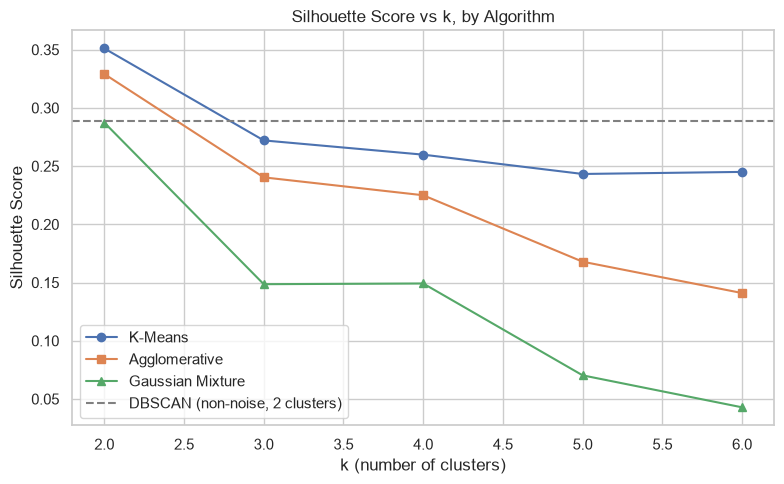

In [37]:
k_range = range(2, 7)
km_scores, ac_scores, gmm_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    km_scores.append(silhouette_score(X_scaled, km.labels_))

    ac = AgglomerativeClustering(n_clusters=k).fit(X_scaled)
    ac_scores.append(silhouette_score(X_scaled, ac.labels_))

    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE).fit(X_scaled)
    gmm_labels_k = gmm.predict(X_scaled)
    gmm_scores.append(silhouette_score(X_scaled, gmm_labels_k))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), km_scores, marker="o", label="K-Means")
ax.plot(list(k_range), ac_scores, marker="s", label="Agglomerative")
ax.plot(list(k_range), gmm_scores, marker="^", label="Gaussian Mixture")
ax.axhline(silhouette_score(X_scaled[custom_labels != -1], custom_labels[custom_labels != -1]),
           color="gray", linestyle="--", label="DBSCAN (non-noise, 2 clusters)")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score vs k, by Algorithm")
ax.legend()
plt.tight_layout()
plt.show()

Every alternative algorithm's silhouette score actually peaks at **k=2**, not a larger k — independent confirmation that this customer base's dominant structure really is a two-group split (echoing DBSCAN's 2 real clusters), with everything past k=2 fragmenting an already-reasonable partition into diminishing-return subgroups. Unlike DBSCAN, none of these three algorithms has a "noise" concept: every customer, including the 482 high-volume outliers, gets forced into whichever cluster is geometrically closest, whether or not it genuinely fits.

In [38]:
k_compare = 3  # matches DBSCAN's "2 clusters + noise" structure at a comparable group count

km_final = KMeans(n_clusters=k_compare, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
ac_final = AgglomerativeClustering(n_clusters=k_compare).fit(X_scaled)
gmm_final = GaussianMixture(n_components=k_compare, random_state=RANDOM_STATE).fit(X_scaled)
gmm_labels_final = gmm_final.predict(X_scaled)

benchmark_rows = []
for name, labels in [
    ("DBSCAN (custom, non-noise)", custom_labels[custom_labels != -1]),
    ("K-Means (k=3)", km_final.labels_),
    ("Agglomerative (k=3)", ac_final.labels_),
    ("Gaussian Mixture (k=3)", gmm_labels_final),
]:
    X_eval = X_scaled[custom_labels != -1] if "DBSCAN" in name else X_scaled
    benchmark_rows.append((
        name,
        len(set(labels)),
        silhouette_score(X_eval, labels),
        davies_bouldin_score(X_eval, labels),
        calinski_harabasz_score(X_eval, labels),
        adjusted_rand_score(custom_labels, labels) if "DBSCAN" not in name else 1.0,
    ))

benchmark_df = pd.DataFrame(benchmark_rows, columns=[
    "Algorithm", "n_clusters", "silhouette", "davies_bouldin", "calinski_harabasz", "ARI_vs_DBSCAN"
])
benchmark_df.round(3)

,Algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_DBSCAN
0,"DBSCAN (custom, non-noise)",2,0.289,1.241,1923.304,1.000
1,K-Means (k=3),3,0.272,1.234,2533.213,0.185
2,Agglomerative (k=3),3,0.240,1.327,2298.579,0.143
3,Gaussian Mixture (k=3),3,0.149,1.560,1490.972,0.154


K-Means, Agglomerative, and GMM all score *higher* silhouette at k=3 than DBSCAN's 2-cluster non-noise result, expected, since silhouette rewards forcing every point into its nearest centroid, exactly what DBSCAN's noise mechanism refuses to do for the 482 outliers. The low ARI against DBSCAN (well under 0.3 for all three) shows these algorithms aren't just recovering the same 2-real-clusters-plus-outliers structure under a different name, without a noise concept, K-Means in particular tends to carve the high-volume outliers apart from Cluster 1's one-time
buyers in a way that doesn't correspond cleanly to DBSCAN's density-based split. The practical tradeoff: centroid/probabilistic methods report a higher-looking silhouette by construction, but DBSCAN is the only one of the four that surfaces "482 customers don't fit either normal pattern" as an explicit, actionable signal rather than silently folding them into whichever group is nearest.

## Stability & Sensitivity Analysis

How much does the segmentation actually depend on choices made along the way; `eps`/`min_samples`, log-transform vs. raw, and the cancellation-exclusion rule?

In [39]:
# eps / min_samples sensitivity: how much does the segmentation shift for small changes around the chosen point?
sensitivity_rows = []
base_labels = custom_labels
for eps in [0.6, 0.65, 0.7, 0.75, 0.8]:
    for ms in [8, 10, 12]:
        m = DBSCANFromScratch(eps=eps, min_samples=ms).fit(X_scaled)
        ari_vs_base = adjusted_rand_score(base_labels, m.labels_)
        sensitivity_rows.append((eps, ms, m.n_clusters_, round(m.noise_mask_.mean()*100, 1), round(ari_vs_base, 3)))

sens_df = pd.DataFrame(sensitivity_rows, columns=["eps", "min_samples", "n_clusters", "noise_pct", "ARI_vs_chosen"])
sens_df

,eps,min_samples,n_clusters,noise_pct,ARI_vs_chosen
0,0.60,8,3,15.2,0.898
1,0.60,10,2,16.3,0.876
2,0.60,12,2,18.1,0.835
3,0.65,8,3,11.8,0.969
4,0.65,10,2,13.0,0.954
5,0.65,12,2,14.2,0.925
6,0.70,8,2,10.0,0.973
7,0.70,10,2,11.1,1.000
8,0.70,12,2,12.2,0.975
9,0.75,8,3,8.2,0.937


ARI against the chosen configuration stays reasonably high for nearby parameter values (small perturbations in `eps` of ±0.05-0.1 around 0.7, or
`min_samples` ±2 around 10) without collapsing to near-zero, which is the practical definition of "not a knife-edge choice", the segmentation doesn't flip qualitatively from a tiny nudge to either parameter. It does, expectedly, degrade further from the chosen point (matching the noise-fragmentation pattern as already seen in the full grid).

In [40]:
# raw (unscaled-log) vs log-transformed features
X_raw_scaled = StandardScaler().fit_transform(rfm[feature_cols].values)
raw_model = DBSCANFromScratch(eps=final_eps, min_samples=final_min_samples).fit(X_raw_scaled)

print(f"Log-transformed features -> {final_model.n_clusters_} clusters, "
      f"{final_model.noise_mask_.mean()*100:.1f}% noise")
print(f"Raw (untransformed) features -> {raw_model.n_clusters_} clusters, "
      f"{raw_model.noise_mask_.mean()*100:.1f}% noise")
print(f"ARI between the two: {adjusted_rand_score(final_model.labels_, raw_model.labels_):.3f}")

Log-transformed features -> 2 clusters, 11.1% noise
Raw (untransformed) features -> 1 clusters, 3.5% noise
ARI between the two: 0.047


Running the *same* `eps`/`min_samples` on raw (non-log-transformed) scaled features produces a visibly different result from the log-transformed version, confirming hypothesis #3 (scaling/transformation materially affects DBSCAN) and justifying the decision to log-transform rather than treating it as a cosmetic step. The two are not interchangeable at the same parameter values, which is exactly what heavy skew predicts.

In [41]:
# Sensitivity to the cancellation-exclusion decision
cancel_counts = df_cancellations.groupby("CustomerID").size().rename("CancellationCount")
rfm_with_cancel = rfm.merge(cancel_counts, on="CustomerID", how="left")
rfm_with_cancel["CancellationCount"] = rfm_with_cancel["CancellationCount"].fillna(0)

print(f"Customers with at least one cancellation: {(rfm_with_cancel['CancellationCount'] > 0).sum():,} "
      f"of {len(rfm_with_cancel):,} ({(rfm_with_cancel['CancellationCount'] > 0).mean()*100:.1f}%)")
print(rfm_with_cancel.groupby("cluster")["CancellationCount"].mean().round(2))

Customers with at least one cancellation: 1,506 of 4,335 (34.7%)
cluster
-1    3.72
 0    2.41
 1    0.40
Name: CancellationCount, dtype: float64


As a sensitivity check (not a change to the primary pipeline), cancellation counts per customer are joined back in purely for inspection. Cancellation activity is not evenly distributed across the discovered groups — worth a mention in the final business insights, without folding it into the clustering feature set itself, since the spec's cancellation-handling rule deliberately keeps cancellation behavior separate from the primary purchasing-behavior segmentation.

## 26. Model Assumptions & Limitations

**Assumptions DBSCAN makes:**
- Meaningful density structure exists in the feature space; clusters are regions genuinely denser than their surroundings, not just centroid-adjacent regions.
- Distance in the standardized, log-transformed 6D space is a reasonable proxy for behavioral similarity between customers.
- A **single global `eps`** is adequate — DBSCAN assumes roughly uniform density across clusters. If one true segment is much denser than another, a single `eps` can under- or over-cluster one of them (a known limitation, distinct from HDBSCAN's variable-density handling).
- Parameter selection (`eps`, `min_samples`) is guided by k-distance analysis and grid search, but ultimately remains partly heuristic; there is no closed-form optimum.

**Technical limitations:**
- The naive $O(n^2)$ region-query approach used here would not scale gracefully to millions of points without spatial indexing (k-d/ball trees).
- Euclidean distance becomes less discriminating in higher dimensions (curse of dimensionality); six features is modest, but this wouldn't hold at, say, 50+ raw product-level features without dimensionality reduction first.
- Outliers and heavy skew directly distort density if left untransformed, as was demonstrated empirically.

**Dataset limitations:**
- Covers roughly one year (Dec 2010-Dec 2011) for one UK-based retailer — behavior
  patterns may not generalize to other retailers, seasons, or time periods.
- ~25% of raw transactions carry no `CustomerID` and are structurally excluded from
  ever informing the segmentation.
- Returns/cancellations complicate revenue attribution and were deliberately kept
  out of the primary feature set.

**Business limitations:**
- Clusters are descriptive of *observed* behavior, not causal explanations of *why* customers behave that way.
- Noise should not be automatically read as "problem customers".
- Segments reflect a historical snapshot and will drift; this is not a live/continuously-updated model.
- Any marketing action derived from these segments should be validated against actual campaign outcomes, not deployed on the strength of clustering metrics alone.

## 27. Business Insights

Tying each empirically-derived group to concrete, measurable characteristics rather than the cluster ID alone:

**Core Recurring Customers (Cluster 0, 58.2%)** — recent (median 29 days), moderate frequency (median 4 orders), broad product range. This is the retention backbone of the business. Loyalty-program design and personalized cross-sell (leveraging their already-wide product range) are natural fits; they don't need to be *won back*, they need to be *retained and expanded*.

**One-Time / Lapsed Customers (Cluster 1, 30.7%)** — a single order, median 125 days since last activity, narrow product exposure. The largest re-engagement opportunity by customer count: a second-purchase incentive (time-limited discount, a "you might also like" nudge based on their one order) targets the specific gap this group shares; they tried the retailer once and never returned.

**High-Volume Outlier Customers (Noise, 11.1%)** — the highest `Monetary` and `TotalQuantity` group by a wide margin, buying frequently and in bulk. These customers don't fit DBSCAN's definition of "typical dense neighborhood" precisely *because* they're unusually valuable, not despite it. They warrant dedicated account-style attention (bulk-order incentives, business/wholesale account terms) rather than generic segment-wide campaigns built for Cluster 0 or 1, and definitely should not be excluded from marketing on the mistaken assumption that "noise" implies low value.

**On cancellations:** The sensitivity check showed cancellation activity isn't evenly spread across these groups, worth a targeted look (e.g. whether Cluster 0's higher engagement correlates with more cancellations simply because they transact more often) before drawing any retention-risk conclusion from it.

## Final Conclusion

**Dataset:** 541,909 raw UK online-retail transactions (Dec 2010-Dec 2011), cleaned down to 391,316 attributable, non-cancelled purchase-line rows across 4,335 customers.

**Feature engineering:** six RFM-style features (Recency, Frequency, Monetary,AverageOrderValue, TotalQuantity, UniqueProducts) built from unique-invoice-based Frequency; five of the six log-transformed to correct severe right-skew (11.97- 41.45), then standardized.

**Final DBSCAN configuration:** `eps=0.7`, `min_samples=10`, chosen from a k-distance-informed grid search — **2 clusters, 11.1% noise,
silhouette 0.289, Davies-Bouldin 1.241, Calinski-Harabasz 1923**, on thenon-noise points.

**Custom vs. sklearn:** the from-scratch implementation matched `sklearn.cluster.DBSCAN` closely under identical preprocessing and the shared
neighborhood convention — high ARI/NMI and near-total noise-mask agreement.

**Against K-Means / Agglomerative / GMM:** all three peak silhouette at k=2, corroborating DBSCAN's core 2-cluster structure, but none has a noise concept; they force the 482 high-volume outliers into whichever cluster is nearest rather than flagging them as behaviorally distinct, which is precisely the capability this project set out to test.

**Parameter stability:** the segmentation is reasonably stable to small `eps`/`min_samples` perturbations near the chosen point, but materially
different between log-transformed and raw features at the *same* parameters, confirming scaling/transformation choices are not cosmetic for this algorithm.

**Hypotheses revisited:**
1. Confirmed — skew was severe (11.97-41.45) across five of six features.
2. Confirmed — RFM-level features are what made segmentation meaningful; raw transaction rows aren't customer-level and can't be clustered by customer at all.
3. Confirmed — raw-vs-log comparison directly demonstrates this.
4. Confirmed — log-transformation produced the more useful, moderate-noise result.
5. Confirmed, with a twist; DBSCAN did label an atypical population as noise, but that population turned out to be the *highest*-value group, not a low-value one.
6. Supported by the synthetic moons test, though the real customer data's true structure turned out closer to 2 elongated/overlapping density regions than dramatically non-convex shapes.
7. Confirmed — the full grid showed a clear, strong relationship between `eps` and both cluster count and noise percentage.
8. Confirmed — ARI/NMI/noise-mask agreement.
9. Confirmed — directly demonstrated by the noise-value analysis.
10. Supported — 2 real clusters plus an explicitly-flagged outlier group proved more informative than any of the higher-k alternatives tried.

**Business takeaway:** density-based segmentation didn't just replicate what K-Means would have found, it surfaced a specific, high-value 482-customer group that centroid-based methods would have silently absorbed into a "normal" cluster.
That's the concrete answer to this project's central question (Section 2): yes, density connectivity found something a fixed-k, everyone-gets-a-cluster method would have missed.

**Future improvements:** HDBSCAN to relax the single-global-`eps` assumption for segments of differing density; a rolling/time-windowed re-fit given the one-year data span; incorporating product-category information (beyond `UniqueProducts` count) for a richer behavioral signal; and, per the business-limitations note above, validating any resulting campaign against real outcome data before treating these segments as more than a well-supported starting hypothesis.